📈 Téléchargement des données boursières en cours...


[*********************100%***********************]  10 of 10 completed



--- TABLEAU COMPARATIF : SENTIMENT VS BOURSE ---
  ticker  vader_mean  stock_return_pct
0    ABT    0.210767          4.871908
1      A    0.179097          3.298993
2    AOS    0.166650          0.884676
3    AES    0.161430          0.135780
4    MMM    0.151560         -1.563847
5    ACN    0.069013          5.449714
6   ABBV    0.060380          6.037033
7    AFL    0.056793         -2.185843
8   ADBE    0.043573          4.639800
9    AMD   -0.100583        -11.206481


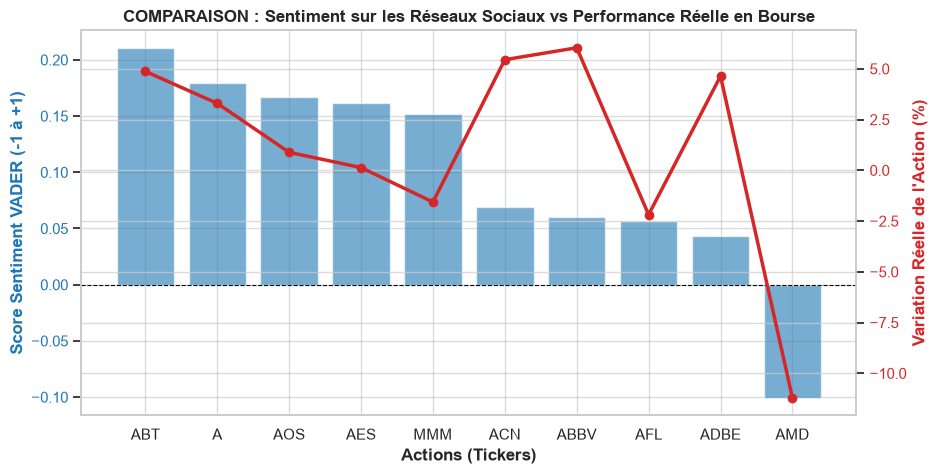


✅ Graphique 'comparaison_sentiment_vs_bourse.png' généré !


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yfinance as yf

# 1. Charger les données de sentiment agrégées
df_sentiment = pd.read_csv("stocktwits_sentiment_summary.csv")

# 2. Récupérer les cours de bourse réels via yfinance
tickers_list = df_sentiment["ticker"].tolist()

print("📈 Téléchargement des données boursières en cours...")
# On récupère les données boursières des 7 derniers jours
stock_data = yf.download(tickers_list, period="7d", interval="1d")["Close"]

# Calcul du pourcentage de variation du prix sur la période
price_change = (
    (stock_data.iloc[-1] - stock_data.iloc[0]) / stock_data.iloc[0]
) * 100
df_market = price_change.reset_index()
df_market.columns = ["ticker", "stock_return_pct"]

# 3. Fusionner les données (Sentiment + Performance Boursière)
df_merged = pd.merge(df_sentiment, df_market, on="ticker")

print("\n--- TABLEAU COMPARATIF : SENTIMENT VS BOURSE ---")
print(df_merged[["ticker", "vader_mean", "stock_return_pct"]])

# 4. Graphique comparatif simple côte à côte
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Axe 1 : Sentiment Réseaux Sociaux (Barres Bleues)
color = "tab:blue"
ax1.set_xlabel("Actions (Tickers)", fontweight="bold")
ax1.set_ylabel("Score Sentiment VADER (-1 à +1)", color=color, fontweight="bold")
bars = ax1.bar(
    df_merged["ticker"],
    df_merged["vader_mean"],
    color=color,
    alpha=0.6,
    label="Sentiment Social",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.axhline(0, color="black", linestyle="--", linewidth=0.8)

# Axe 2 : Variation du Prix en Bourse (Ligne/Points Rouges)
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel(
    "Variation Réelle de l'Action (%)", color=color, fontweight="bold"
)
ax2.plot(
    df_merged["ticker"],
    df_merged["stock_return_pct"],
    color=color,
    marker="o",
    linewidth=2.5,
    label="Variation Bourse (%)",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "COMPARAISON : Sentiment sur les Réseaux Sociaux vs Performance Réelle en Bourse",
    fontsize=12,
    fontweight="bold",
)
plt.savefig("comparaison_sentiment_vs_bourse.png", bbox_inches="tight")
plt.show()

print(
    "\n✅ Graphique 'comparaison_sentiment_vs_bourse.png' généré !"
)